# Lumbar Spine MRI + MedGemma — Local Demo

This is a **self-contained demo** version of the full RSNA notebook.  
It works with **just a handful of DICOM files** — no need to download the entire 35 GB dataset.

## Do I need to download the full dataset?

**No.** The full competition dataset is ~35 GB and contains ~147,000 DICOM files.  
For learning purposes, even 1–10 `.dcm` files from a single series are enough to demonstrate:
- How DICOM files are structured and loaded
- Window/Level normalization
- Multi-slice volume visualization
- MedGemma multimodal API calls

If you later want the full dataset, the Kaggle CLI command is:
```bash
kaggle competitions download -c rsna-2024-lumbar-spine-degenerative-classification -p ./data/rsna-2024-lumbar-spine/
```
But for this demo notebook, we use the few files already present under `./data/rsna_lumbar_spine/`.

## What we have locally

```
data/rsna_lumbar_spine/
├── 10.dcm   (instance 10, T2, 320×320, 12-bit)
├── 16.dcm   (instance 16)
├── 24.dcm   (instance 24)
├── 35.dcm   (instance 35)
└── 60.dcm   (instance 60)
```

All five files belong to the **same study and same T2 series**, so they form a (sparse) 3D volume.

## Kernel
Select the **`ml_env`** conda kernel before running: *Kernel → Change Kernel → ml_env*

## 📦 Install / verify dependencies

In [1]:
# Verify required packages are present; install any that are missing
import importlib, subprocess, sys

required = ["pydicom", "PIL", "matplotlib", "numpy", "requests", "ipywidgets"]
missing  = [pkg for pkg in required if importlib.util.find_spec(pkg) is None]

if missing:
    print(f"Installing: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install"] + missing)
else:
    print("All required packages are already installed.")

All required packages are already installed.


## 📦 Imports

In [2]:
import base64
import io
import mimetypes
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pydicom
import requests
from PIL import Image
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")

try:
    import ipywidgets as widgets
    from IPython.display import clear_output
    widgets_available = True
except ImportError:
    widgets_available = False

print(f"Python  : {sys.version.split()[0]}")
print(f"pydicom : {pydicom.__version__}")
print(f"Pillow  : {Image.__version__}")
print(f"Widgets : {widgets_available}")

Python  : 3.11.9
pydicom : 3.0.2
Pillow  : 11.1.0
Widgets : True


## ⚙️ Configuration

The notebook calls the **LM Studio OpenAI-compatible endpoint** on your Windows 11 host.  
Override the defaults with environment variables if your IP differs:
```bash
export LM_STUDIO_BASE_URL=http://192.168.1.2:1234/v1
export LM_STUDIO_MODEL=medgemma-4b-it
```
Find your Windows host IP from WSL with: `cat /etc/resolv.conf | grep nameserver`

In [3]:
import sys

LM_STUDIO_BASE_URL = os.getenv("LM_STUDIO_BASE_URL", "http://192.168.1.2:1234/v1")
LM_STUDIO_MODEL    = os.getenv("LM_STUDIO_MODEL",    "medgemma-4b-it")

# Folder containing the downloaded .dcm files (flat — no study/series subdirectories)
LOCAL_DICOM_DIR = Path("./data/rsna_lumbar_spine")

print(f"LM Studio endpoint : {LM_STUDIO_BASE_URL}")
print(f"Model              : {LM_STUDIO_MODEL}")
print(f"DICOM directory    : {LOCAL_DICOM_DIR.resolve()}")
print(f"Directory exists   : {LOCAL_DICOM_DIR.exists()}")

dcm_files = sorted(LOCAL_DICOM_DIR.glob("*.dcm")) if LOCAL_DICOM_DIR.exists() else []
print(f"DICOM files found  : {len(dcm_files)}  →  {[f.name for f in dcm_files]}")

LM Studio endpoint : http://192.168.1.2:1234/v1
Model              : medgemma-4b-it
DICOM directory    : /home/bk_anupam/code/ML/DeepLearningWSL/Training/AI_In_HealthCare/ImageDiagnosis/data/rsna_lumbar_spine
Directory exists   : True
DICOM files found  : 5  →  ['10.dcm', '16.dcm', '24.dcm', '35.dcm', '60.dcm']


---

## 🗂️ What is DICOM?

**DICOM** (Digital Imaging and Communications in Medicine) is the universal standard for storing, transmitting, and displaying medical imaging data. Every MRI, CT scan, or X-ray produced in a modern hospital is stored as a DICOM file.

### Why DICOM instead of JPEG/PNG?

| Property | JPEG/PNG | DICOM (.dcm) |
| :--- | :--- | :--- |
| **Bit depth** | 8-bit (256 levels) | 12–16-bit (4,096–65,536 levels) |
| **Metadata** | Minimal (EXIF) | Rich: patient ID, acquisition params, orientation |
| **Multi-frame** | No | Yes — a single file can hold a 3D volume |
| **Coordinate system** | Pixel-only | Physical world coordinates (mm) |
| **Clinical use** | Never used in radiology | Mandatory standard globally |

### Key DICOM metadata fields
```
StudyInstanceUID        → unique ID for the entire imaging exam
SeriesInstanceUID       → unique ID for one series (e.g., all sagittal T2 slices)
SOPInstanceUID          → unique ID for a single image slice
Modality                → MR, CT, CR, DX, …
SeriesDescription       → e.g. "Sagittal T2/STIR", "Axial T2", "T2"
ImagePositionPatient    → 3D position (x, y, z) in mm of the first pixel
ImageOrientationPatient → direction cosines — defines the imaging plane
PixelSpacing            → physical pixel size in mm [row_spacing, col_spacing]
SliceThickness          → thickness of each 2D slice in mm
RescaleSlope/Intercept  → converts stored integers → calibrated values
BitsStored              → typically 12 for MRI, 16 for CT
WindowCenter/Width      → radiologist display preset
```

### MRI series used in lumbar spine studies

| Series | Plane | Best for |
| :--- | :--- | :--- |
| **Sagittal T1** | Side view | Vertebral body height, fatty marrow |
| **Sagittal T2/STIR** | Side view | Disc hydration, spinal canal, cord signal |
| **Axial T2** | Cross-section | Foraminal narrowing, lateral recess, central canal |

> In T2-weighted MRI, **fluid appears bright** (white). Healthy intervertebral discs are bright because they contain water-rich nucleus pulposus. Degenerated discs appear dark.

---

## 🩻 Load and inspect DICOM files

In [4]:
# ── Core DICOM helpers ─────────────────────────────────────────────────────

def load_dicom(path: Path) -> pydicom.Dataset:
    """Load a DICOM file and return the dataset."""
    return pydicom.dcmread(str(path))


def print_dicom_metadata(ds: pydicom.Dataset, filename: str = "") -> None:
    """Print a curated subset of clinically relevant DICOM tags."""
    tags = [
        ("Modality",               "Modality"),
        ("SeriesDescription",      "Series description"),
        ("BodyPartExamined",       "Body part"),
        ("Rows",                   "Image rows (px)"),
        ("Columns",                "Image cols (px)"),
        ("BitsStored",             "Bits stored"),
        ("PixelSpacing",           "Pixel spacing (mm)"),
        ("SliceThickness",         "Slice thickness (mm)"),
        ("ImagePositionPatient",   "Image position (mm)"),
        ("ImageOrientationPatient","Image orientation"),
        ("WindowCenter",           "Window center"),
        ("WindowWidth",            "Window width"),
        ("RescaleSlope",           "Rescale slope"),
        ("RescaleIntercept",       "Rescale intercept"),
        ("InstanceNumber",         "Instance number"),
        ("StudyInstanceUID",       "Study UID (first 20)"),
        ("SeriesInstanceUID",      "Series UID (first 20)"),
    ]
    header = f"DICOM Metadata — {filename}" if filename else "DICOM Metadata"
    print(f"\n{header:=^60}")
    for attr, label in tags:
        value = getattr(ds, attr, "— not present —")
        if attr in ("StudyInstanceUID", "SeriesInstanceUID"):
            value = str(value)[:20] + "…"
        print(f"  {label:<30}: {value}")
    print("=" * 60)


def get_pixel_array(ds: pydicom.Dataset) -> np.ndarray:
    """
    Return calibrated floating-point pixel values.
    Applies RescaleSlope / RescaleIntercept (converts raw integers to
    Hounsfield Units for CT, or arbitrary units for MRI).
    """
    pixels    = ds.pixel_array.astype(np.float32)
    slope     = float(getattr(ds, "RescaleSlope",     1.0))
    intercept = float(getattr(ds, "RescaleIntercept", 0.0))
    return pixels * slope + intercept


print("DICOM helpers defined.")

DICOM helpers defined.


In [5]:
# ── Load all DICOM files from the local flat directory ─────────────────────
if not dcm_files:
    raise FileNotFoundError(
        f"No .dcm files found in {LOCAL_DICOM_DIR.resolve()}\n"
        "Place at least one .dcm file there and re-run this cell."
    )

datasets = [load_dicom(f) for f in dcm_files]
# Sort by InstanceNumber so slices are in anatomical order
datasets.sort(key=lambda ds: int(getattr(ds, "InstanceNumber", 0)))
pixel_arrays = [get_pixel_array(ds) for ds in datasets]

print(f"Loaded {len(datasets)} DICOM slices")
print(f"Instance numbers  : {[int(getattr(ds, 'InstanceNumber', '?')) for ds in datasets]}")
print(f"Image size        : {datasets[0].Rows} × {datasets[0].Columns} px")
print(f"Bits stored       : {getattr(datasets[0], 'BitsStored', '?')}")
print(f"Series description: {getattr(datasets[0], 'SeriesDescription', '?')}")
print(f"Pixel value range : [{min(p.min() for p in pixel_arrays):.0f},"
      f" {max(p.max() for p in pixel_arrays):.0f}]")

Loaded 5 DICOM slices
Instance numbers  : [10, 16, 24, 35, 60]
Image size        : 320 × 320 px
Bits stored       : 12
Series description: T2
Pixel value range : [0, 1586]


In [6]:
# ── Print detailed metadata for the first slice ────────────────────────────
print_dicom_metadata(datasets[0], filename=dcm_files[0].name)


==================DICOM Metadata — 10.dcm===================
  Modality                      : — not present —
  Series description            : T2
  Body part                     : — not present —
  Image rows (px)               : 320
  Image cols (px)               : 320
  Bits stored                   : 12
  Pixel spacing (mm)            : [0.5, 0.5]
  Slice thickness (mm)          : 3.5
  Image position (mm)           : [-66.404123696311, -8.0819529038256, -428.18402042771]
  Image orientation             : [0.99944538826001, 0.0171142607981, -0.0285660281301, -0.020237366989, 0.99340140339889, -0.1128897723554]
  Window center                 : 530
  Window width                  : 1129
  Rescale slope                 : — not present —
  Rescale intercept             : — not present —
  Instance number               : 10
  Study UID (first 20)          : 100206310…
  Series UID (first 20)         : 100206310.1012284084…


---

## 🖼️ Window / Level normalization

Raw MRI values span a large dynamic range (0–4095 for 12-bit). Radiologists apply a **Window/Level** transform to isolate the contrast they care about:

$$
I_{\text{display}} = \frac{I_{\text{raw}} - \bigl(\text{Level} - \tfrac{\text{Window}}{2}\bigr)}{\text{Window}} \times 255
$$

| Parameter | Meaning |
| :--- | :--- |
| **Level** (Window Center) | Midpoint of the intensity range of interest |
| **Window** (Window Width) | Span of intensities mapped to 0–255 display range |

Values below the lower bound → black; above the upper bound → white.

In [7]:
def apply_window_level(
    pixels: np.ndarray,
    window: float | None = None,
    level:  float | None = None,
) -> np.ndarray:
    """
    Apply Window/Level contrast stretching and return an 8-bit uint8 array.
    If window/level are None, auto-scales using 1st–99th percentile of the image.
    """
    if window is None or level is None:
        low    = np.percentile(pixels, 1)
        high   = np.percentile(pixels, 99)
        window = high - low
        level  = (high + low) / 2.0

    lower     = level - window / 2.0
    upper     = level + window / 2.0
    stretched = np.clip(pixels, lower, upper)
    stretched = (stretched - lower) / (upper - lower + 1e-8) * 255.0
    return stretched.astype(np.uint8)


def dicom_to_pil(
    ds: pydicom.Dataset,
    window: float | None = None,
    level:  float | None = None,
) -> Image.Image:
    """
    Convert a DICOM dataset to an RGB PIL Image.
    Uses auto W/L if window/level are not provided.
    """
    pixels = get_pixel_array(ds)
    normed = apply_window_level(pixels, window, level)
    if normed.ndim == 2:
        return Image.fromarray(normed, mode="L").convert("RGB")
    return Image.fromarray(normed, mode="RGB")


print("Window/Level helpers defined.")

Window/Level helpers defined.


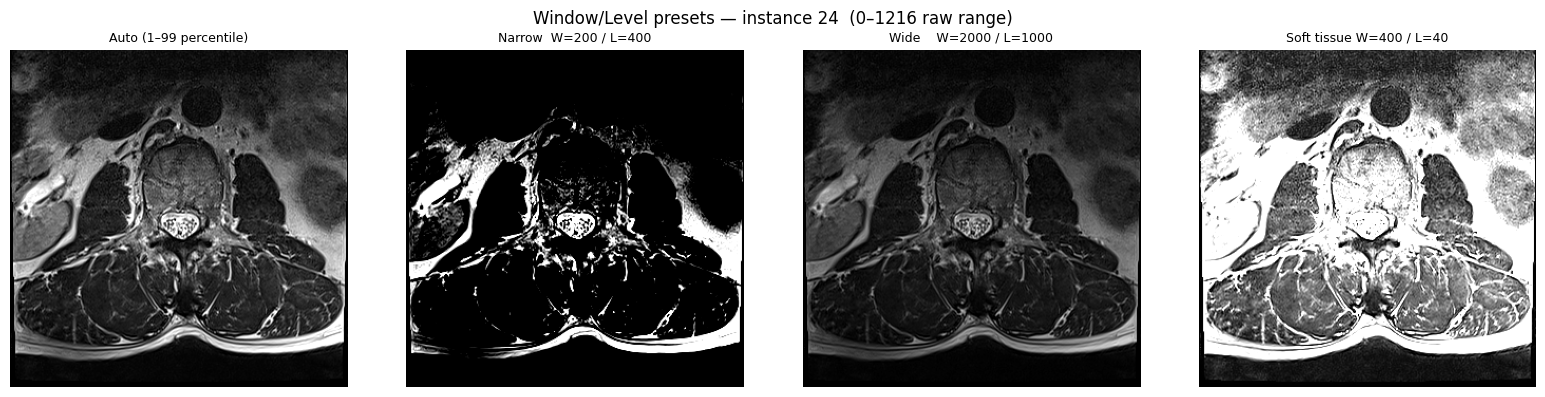

In [8]:
# ── Compare W/L presets side-by-side on one slice ──────────────────────────
demo_pixels = pixel_arrays[len(pixel_arrays) // 2]  # middle slice
demo_ds     = datasets[len(datasets) // 2]

wl_presets = [
    ("Auto (1–99 percentile)", None,  None),
    ("Narrow  W=200 / L=400",  200,   400),
    ("Wide    W=2000 / L=1000",2000,  1000),
    ("Soft tissue W=400 / L=40",400,   40),
]

fig, axes = plt.subplots(1, len(wl_presets), figsize=(16, 4))
fig.suptitle(
    f"Window/Level presets — instance {getattr(demo_ds, 'InstanceNumber', '?')}  "
    f"({demo_pixels.min():.0f}–{demo_pixels.max():.0f} raw range)",
    fontsize=12,
)

for ax, (label, window, level) in zip(axes, wl_presets):
    normed = apply_window_level(demo_pixels, window, level)
    ax.imshow(normed, cmap="gray")
    ax.set_title(label, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

---

## 📚 Visualizing the volume

Even with just 5 slices we can show the contact sheet and an interactive scroller.  
The instance numbers (10, 16, 24, 35, 60) are not consecutive — these are sparse samples from a larger 3D volume.

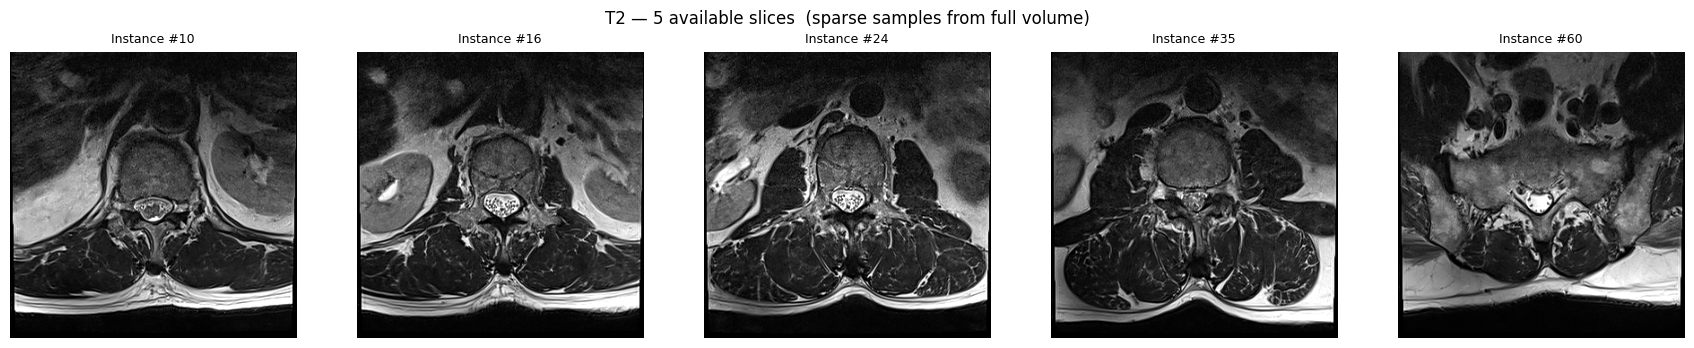

In [9]:
# ── Contact sheet: all available slices ────────────────────────────────────
n    = len(pixel_arrays)
cols = min(n, 5)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
axes = np.array(axes).flatten()
series_desc = getattr(datasets[0], "SeriesDescription", "Unknown")
fig.suptitle(
    f"{series_desc} — {n} available slices  (sparse samples from full volume)",
    fontsize=12,
)

for idx, (pixels, ds) in enumerate(zip(pixel_arrays, datasets)):
    normed   = apply_window_level(pixels)
    inst_num = getattr(ds, "InstanceNumber", idx)
    axes[idx].imshow(normed, cmap="gray")
    axes[idx].set_title(f"Instance #{inst_num}", fontsize=9)
    axes[idx].axis("off")

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [10]:
# ── Interactive slice scroller (requires ipywidgets) ───────────────────────
if widgets_available:
    slider = widgets.IntSlider(
        value=0, min=0, max=len(datasets) - 1, step=1,
        description="Slice:",
        continuous_update=True,
        layout=widgets.Layout(width="500px"),
    )
    out = widgets.Output()

    def _update(change):
        idx = change["new"]
        ds  = datasets[idx]
        px  = pixel_arrays[idx]
        with out:
            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(5, 5))
            ax.imshow(apply_window_level(px), cmap="gray")
            ax.set_title(
                f"Instance #{getattr(ds, 'InstanceNumber', idx)}  |  "
                f"{getattr(ds, 'SeriesDescription', '')}  |  "
                f"value range [{px.min():.0f}, {px.max():.0f}]",
                fontsize=9,
            )
            ax.axis("off")
            plt.tight_layout()
            plt.show()

    slider.observe(_update, names="value")
    _update({"new": 0})
    display(widgets.VBox([slider, out]))
else:
    print("ipywidgets not available. Install it for the interactive scroller.")

---

## 🤖 MedGemma API helpers

The DICOM image must be converted to a Base64-encoded PNG before it can be sent to the LM Studio API.  
This is necessary because:
1. The LM Studio OpenAI-compatible API expects standard image formats (JPEG/PNG), not DICOM
2. DICOM pixel values are 12-bit; we must apply W/L normalization to 8-bit first
3. Base64 encoding embeds the image inline in the JSON request (no separate file upload needed)

In [11]:
def pil_to_data_url(image: Image.Image, fmt: str = "PNG") -> str:
    """Encode a PIL Image as a Base64 PNG data URL suitable for the API."""
    buf = io.BytesIO()
    image.save(buf, format=fmt)
    encoded = base64.b64encode(buf.getvalue()).decode("utf-8")
    return f"data:image/{fmt.lower()};base64,{encoded}"


def build_messages(
    system_prompt: str,
    user_prompt: str,
    image_data_urls: list[str],
) -> list[dict]:
    """
    Build an OpenAI-compatible messages list.
    Supports sending multiple images in a single user turn.
    """
    content: list[dict] = [{"type": "text", "text": user_prompt}]
    for url in image_data_urls:
        content.append({"type": "image_url", "image_url": {"url": url}})
    return [
        {"role": "system", "content": system_prompt},
        {"role": "user",   "content": content},
    ]


def call_medgemma(
    messages: list[dict],
    max_tokens: int = 800,
    temperature: float = 0.2,
) -> str:
    """POST to the LM Studio /chat/completions endpoint and return the reply."""
    payload = {
        "model":       LM_STUDIO_MODEL,
        "messages":    messages,
        "temperature": temperature,
        "max_tokens":  max_tokens,
    }
    response = requests.post(
        f"{LM_STUDIO_BASE_URL}/chat/completions",
        json=payload,
        timeout=600,
    )
    response.raise_for_status()
    content = response.json()["choices"][0]["message"]["content"]
    if isinstance(content, list):
        content = "\n".join(
            p.get("text", "") for p in content if p.get("type") == "text"
        ).strip()
    return content


SYSTEM_PROMPT = (
    "You are an expert neuroradiologist AI assistant specializing in lumbar spine MRI interpretation. "
    "Produce concise, clinician-facing reports using precise anatomical terminology. "
    "Always state that AI findings must be confirmed by a licensed radiologist before clinical action."
)

print("MedGemma API helpers defined.")

MedGemma API helpers defined.


In [15]:
# ── Quick connectivity test ─────────────────────────────────────────────────
# Calls /models to verify LM Studio is reachable before sending a full image
try:
    r = requests.get(f"{LM_STUDIO_BASE_URL}/models", timeout=50)
    r.raise_for_status()
    model_ids = [m["id"] for m in r.json().get("data", [])]
    print("LM Studio is reachable.")
    print(f"Available models: {model_ids}")
    if LM_STUDIO_MODEL not in model_ids:
        print(f"WARNING: '{LM_STUDIO_MODEL}' not in available models — check LM Studio.")
    else:
        print(f"Target model '{LM_STUDIO_MODEL}' is loaded and ready.")
except requests.exceptions.ConnectionError:
    print("Cannot reach LM Studio — is it running on Windows with the server enabled?")
    print(f"Expected URL: {LM_STUDIO_BASE_URL}")
except Exception as e:
    print(f"Unexpected error: {e}")

LM Studio is reachable.
Available models: ['medgemma-1.5-4b-it', 'medgemma-4b-it', 'text-embedding-nomic-embed-text-v1.5']
Target model 'medgemma-4b-it' is loaded and ready.


---

## 🧠 MedGemma Analysis 1 — Single slice T2 report

We send the **middle slice** of our 5-file set with a structured lumbar spine prompt.  
The prompt asks MedGemma to:
- Assess disc signal at each intervertebral level
- Grade spinal canal stenosis
- Note alignment and vertebral body changes

The response follows the same clinical report structure used in the full RSNA competition notebook.

In [16]:
T2_PROMPT = """
You are reviewing a T2-weighted lumbar spine MRI image (series description: "T2").
This may be a sagittal or axial slice — describe what plane is visible.

Produce a structured radiological report with the following sections:

1. Image plane and orientation
   - State whether this appears to be a sagittal, axial, or coronal slice.

2. Overall alignment (if sagittal)
   - Describe lumbar lordosis (normal / reduced / reversed).
   - Note any spondylolisthesis.

3. Intervertebral disc assessment
   For each visible disc level:
   - Signal intensity (bright = normal; dark = degeneration)
   - Disc height (maintained / reduced / collapsed)
   - Posterior disc contour (normal / bulge / protrusion)

4. Spinal canal / thecal sac
   - Central canal calibre and any thecal sac compression.
   - Grade per level: None / Mild / Moderate / Severe

5. Neural foramina and lateral recesses (if axial)
   - Left and right foraminal patency.
   - Left and right lateral recess patency.

6. Vertebral bodies
   - Compression fractures, Modic endplate changes, bone marrow signal.

7. Summary
   - Most significant finding.
   - Recommended follow-up.

8. Disclaimer
   - State this is AI-generated decision support and must be reviewed by a licensed radiologist.
""".strip()

print(T2_PROMPT)

You are reviewing a T2-weighted lumbar spine MRI image (series description: "T2").
This may be a sagittal or axial slice — describe what plane is visible.

Produce a structured radiological report with the following sections:

1. Image plane and orientation
   - State whether this appears to be a sagittal, axial, or coronal slice.

2. Overall alignment (if sagittal)
   - Describe lumbar lordosis (normal / reduced / reversed).
   - Note any spondylolisthesis.

3. Intervertebral disc assessment
   For each visible disc level:
   - Signal intensity (bright = normal; dark = degeneration)
   - Disc height (maintained / reduced / collapsed)
   - Posterior disc contour (normal / bulge / protrusion)

4. Spinal canal / thecal sac
   - Central canal calibre and any thecal sac compression.
   - Grade per level: None / Mild / Moderate / Severe

5. Neural foramina and lateral recesses (if axial)
   - Left and right foraminal patency.
   - Left and right lateral recess patency.

6. Vertebral bodies


Selected slice: instance #24  (3/5)
Image size    : 320 × 320 px


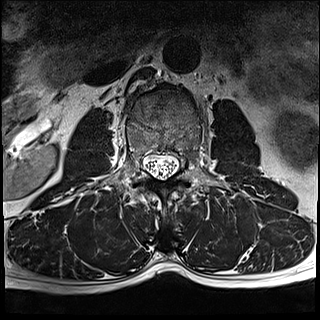


Sending to MedGemma … (30–120 s)


## MedGemma Report — T2 Lumbar Spine MRI

**Instance:** `#24`  |  **Series:** `T2`

Here's an AI-generated report based on the provided image:

1.  **Image plane and orientation:** This appears to be a sagittal slice of the lumbar spine.

2.  **Overall alignment (if sagittal):** Lumbar lordosis is normal. No spondylolisthesis is evident.

3.  **Intervertebral disc assessment:**
    *   L4-5: Signal intensity is bright, indicating normal discs. Disc height appears maintained. Posterior disc contour is normal.
    *   L5-S1: Signal intensity is bright, indicating normal discs. Disc height appears maintained. Posterior disc contour is normal.

4.  **Spinal canal / thecal sac:** Central canal calibre and thecal sac appear unremarkable. No evidence of significant compression at any level assessed. Grade: None.

5.  **Neural foramina and lateral recesses (if axial):** The image plane does not allow for assessment of neural foramina or lateral recesses.

6.  **Vertebral bodies:** No obvious compression fractures, Modic endplate changes, or significant bone marrow signal abnormalities are identified in the provided slice.

7.  **Summary:** The most significant finding is normal lumbar alignment and disc height at L4-5 and L5-S1.

8.  **Disclaimer:** This report is AI-generated decision support and must be reviewed by a licensed radiologist before clinical action.


In [17]:
# ── Select middle slice, display it, then send to MedGemma ─────────────────
mid_idx    = len(datasets) // 2
analysis_ds  = datasets[mid_idx]
analysis_pil = dicom_to_pil(analysis_ds)

inst_num = getattr(analysis_ds, "InstanceNumber", mid_idx)
print(f"Selected slice: instance #{inst_num}  ({mid_idx + 1}/{len(datasets)})")
print(f"Image size    : {analysis_pil.size[0]} × {analysis_pil.size[1]} px")
display(analysis_pil)

# Encode and send
data_url = pil_to_data_url(analysis_pil)
messages = build_messages(SYSTEM_PROMPT, T2_PROMPT, [data_url])

print("\nSending to MedGemma … (30–120 s)")
reply = call_medgemma(messages, max_tokens=900)

report_md = "\n".join([
    "## MedGemma Report — T2 Lumbar Spine MRI",
    "",
    f"**Instance:** `#{inst_num}`  |  **Series:** `{getattr(analysis_ds, 'SeriesDescription', '?')}`",
    "",
    reply,
])
display(Markdown(report_md))

---

## 🧠 MedGemma Analysis 2 — Multi-slice contextual report

Instead of one image, we now send **all 5 slices** as a montage in a single request.  
This gives MedGemma spatial context across the volume — similar to how a radiologist scrolls through the series.

The images are tiled into a single PNG (grid layout) to stay within typical API image limits.

Montage size: 1280 × 256 px  (5 slices)


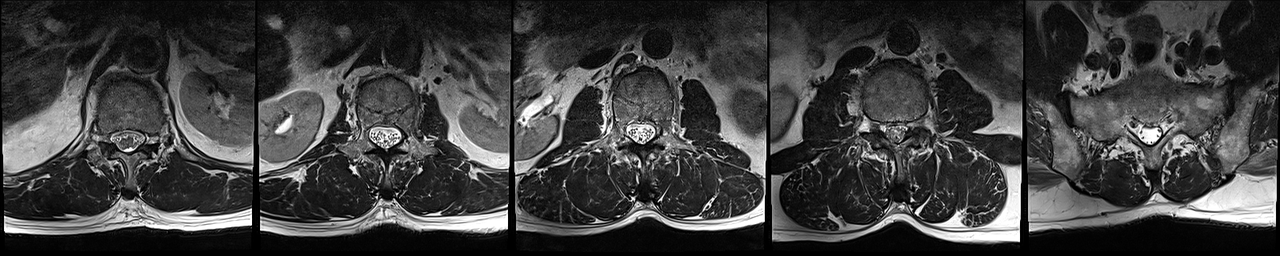

In [18]:
def build_montage(
    pil_images: list[Image.Image],
    cols: int = 5,
    thumb_size: int = 256,
    label_fn=None,
) -> Image.Image:
    """
    Tile a list of PIL images into a single grid montage.
    Each image is resized to thumb_size × thumb_size.
    """
    n    = len(pil_images)
    rows = (n + cols - 1) // cols
    canvas = Image.new("RGB", (cols * thumb_size, rows * thumb_size), color=(20, 20, 20))

    for idx, img in enumerate(pil_images):
        thumb = img.convert("RGB").resize((thumb_size, thumb_size), Image.LANCZOS)
        row, col = divmod(idx, cols)
        canvas.paste(thumb, (col * thumb_size, row * thumb_size))

    return canvas


# Build and display the montage
pil_slices = [dicom_to_pil(ds) for ds in datasets]
montage    = build_montage(pil_slices, cols=len(pil_slices), thumb_size=256)

print(f"Montage size: {montage.size[0]} × {montage.size[1]} px  ({len(pil_slices)} slices)")
display(montage)

In [ ]:
MULTI_SLICE_PROMPT = """
You are reviewing a grid of T2-weighted lumbar spine MRI slices from the same series.
The images are arranged left to right in order of increasing instance number (i.e., moving
through the volume from one end to the other).

Use all slices together to produce a comprehensive report:

1. Series orientation
   - Describe whether these appear to be sagittal, axial, or coronal slices.

2. Volume overview
   - Describe the anatomical structures visible across the series.
   - Note which slice appears to be the most central / most informative.

3. Degenerative findings
   - Identify any disc signal loss, disc height reduction, or posterior disc bulge/protrusion.
   - Note any spinal canal narrowing.

4. Severity grading 
   For each identifiable disc level (L1/L2 through L5/S1), grade:
   - Spinal canal stenosis         : Normal/Mild | Moderate | Severe
   - Left neural foraminal narrowing: Normal/Mild | Moderate | Severe
   - Right neural foraminal narrowing: Normal/Mild | Moderate | Severe
   - Left subarticular stenosis    : Normal/Mild | Moderate | Severe
   - Right subarticular stenosis   : Normal/Mild | Moderate | Severe

5. Most significant finding
   - Identify the single most clinically important abnormality and its location.

6. Limitations
   - State any limitations of this analysis given the sparse slice sampling.

7. Disclaimer
   - State that this is AI decision support and must be confirmed by a licensed radiologist.
""".strip()

print(MULTI_SLICE_PROMPT)

You are reviewing a grid of T2-weighted lumbar spine MRI slices from the same series.
The images are arranged left to right in order of increasing instance number (i.e., moving
through the volume from one end to the other).

Use all slices together to produce a comprehensive report:

1. Series orientation
   - Describe whether these appear to be sagittal, axial, or coronal slices.

2. Volume overview
   - Describe the anatomical structures visible across the series.
   - Note which slice appears to be the most central / most informative.

3. Degenerative findings
   - Identify any disc signal loss, disc height reduction, or posterior disc bulge/protrusion.
   - Note any spinal canal narrowing.

4. Severity grading (RSNA competition format)
   For each identifiable disc level (L1/L2 through L5/S1), grade:
   - Spinal canal stenosis         : Normal/Mild | Moderate | Severe
   - Left neural foraminal narrowing: Normal/Mild | Moderate | Severe
   - Right neural foraminal narrowing: Normal

In [20]:
# ── Send the montage to MedGemma as a single image ──────────────────────────
montage_url = pil_to_data_url(montage)
messages    = build_messages(SYSTEM_PROMPT, MULTI_SLICE_PROMPT, [montage_url])

inst_nums = [int(getattr(ds, 'InstanceNumber', i)) for i, ds in enumerate(datasets)]
print(f"Sending {len(pil_slices)}-slice montage (instances {inst_nums}) to MedGemma …")
reply = call_medgemma(messages, max_tokens=1000)

report_md = "\n".join([
    "## MedGemma Report — Multi-slice T2 Montage",
    "",
    f"**Slices:** instances `{inst_nums}`  |  "
    f"**Series:** `{getattr(datasets[0], 'SeriesDescription', '?')}`",
    "",
    reply,
])
display(Markdown(report_md))

Sending 5-slice montage (instances [10, 16, 24, 35, 60]) to MedGemma …


## MedGemma Report — Multi-slice T2 Montage

**Slices:** instances `[10, 16, 24, 35, 60]`  |  **Series:** `T2`

Here's an AI-generated report based on the provided T2-weighted lumbar spine MRI slices:

**1. Series Orientation:**

The series appears to be **sagittal**.

**2. Volume Overview:**

The images show the vertebral bodies, intervertebral discs (including the posterior longitudinal ligament and annulus fibrosus), spinal canal, neural foramina, and surrounding soft tissues (muscles). The most central/informative slice is likely L4-L5 or L5-S1 as it provides a good view of the disc space and nerve root exit zones.

**3. Degenerative Findings:**

*   Disc signal loss is present at multiple levels.
*   Disc height reduction is noted at several levels (e.g., L4-L5, L5-S1).
*   Posterior disc bulge/protrusion is observed at L4-L5 and L5-S1.
*   Spinal canal narrowing is present in the central spinal canal at multiple levels.

**4. Severity Grading (RSNA Competition Format):**

*   **Spinal Canal Stenosis:** Moderate at L3-L4, L4-L5, L5-S1.
*   **Left Neural Foraminal Narrowing:** Mild at L4-L5, L5-S1.
*   **Right Neural Foraminal Narrowing:** Mild at L4-L5, L5-S1.
*   **Left Subarticular Stenosis:** Mild at L4-L5, L5-S1.
*   **Right Subarticular Stenosis:** Mild at L4-L5, L5-S1.

**5. Most Significant Finding:**

The most clinically significant finding is **moderate spinal canal stenosis at L4-L5 and L5-S1**, potentially contributing to nerve root compression.

**6. Limitations:**

This analysis is limited by the sparse slice sampling provided. A complete assessment requires a full series of T2-weighted images, including sagittal and axial views.

**7. Disclaimer:**

This AI report provides decision support but must be confirmed by a licensed radiologist before clinical action.


---

## 📝 Summary

### What this demo showed

| Step | What we demonstrated |
| :--- | :--- |
| **DICOM loading** | `pydicom.dcmread()`, metadata tags, `pixel_array`, RescaleSlope/Intercept |
| **12-bit pixel range** | Raw values 0–4095; cannot be sent directly to a vision model |
| **Window/Level** | Mapping clinically relevant contrast range to 0–255 display range |
| **Volume visualization** | Contact sheet + interactive scroller across sparse slice set |
| **MedGemma single-slice** | Structured T2 spine report from one mid-series image |
| **MedGemma multi-slice** | Montage of all 5 slices in one request for volume-level reasoning |

### Do you need the full 35 GB dataset?

**For learning and demonstration: No.** A few DICOM files are enough to explore the full pipeline.  
**For competitive modeling:** Yes — the full dataset provides:
- Multiple series per study (Sagittal T1, Sagittal T2/STIR, Axial T2)
- `train.csv` ground-truth severity labels for all 25 condition-level combinations
- `train_label_coordinates.csv` with pixel-level annotation positions

### Downloading more DICOM files selectively
With the Kaggle API you can download just a subset — individual studies are organized as:
```
train_images/<study_id>/<series_id>/<instance>.dcm
```
You can use `kaggle competitions files` to list files and download only specific study folders.

### Next steps
- **Crop to disc level**: use `train_label_coordinates.csv` to crop a 224×224 patch around each labelled disc level and send individual crops for per-level severity prediction.
- **Few-shot prompting**: prepend 2–3 known-label image examples to the prompt to calibrate MedGemma toward the competition's Normal/Mild / Moderate / Severe rubric.
- **Comparison**: run the full RSNA notebook (`rsna_lumbar_spine_medgemma.ipynb`) once you have the complete dataset for the multi-series contextual analysis.